<a href="https://colab.research.google.com/github/sofol-bit/LinSofoNEUR265/blob/main/notebooks/Neuroimaging_04_21_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Neuroimaging

How do we measure brain activity non-invasively in humans? The EEG is one way; however, this technique has its limitations. Specifically, we can't localize signals very well with EEG - that is, we only have a very general idea of where in the brain EEG signals come from. The EEG also picks up artifacts from all of the stuff in between the brain and the skull electrode - bone, hair, and skin. Neuroimaging overcomes these limitations by measuring metabolic activity from specific areas of the brain with high levels of detail.

##By the end of this notebook, you will be able to:

- Plot anatomy and functional MRI scans from individual human participants
- Extract blood oxygen level-dependent (BOLD) activity from specific areas of the brain during a cognitive task
- Use machine learning to characterize the type of task a participant is doing based on BOLD signals

##Introduction

We are going to focus on one specific type of neuroimaging: Magnetic resonance imaging (MRI). MRI uses strong magnetic fields (via magnets) to generate pictures of the brain. Structural MRI provides static views of the brain, while functional MRI (fMRI) provides snapshots of changes in brain activity (blood flow) over time. fMRI takes advantage of the fact that oxygen-rich blood flows to brain areas when they are active - this oxygen-rich blood is carried by hemoglobin, which is resistant to magnetism. In contrast, de-oxygenated blood is magnetic, creating a contrast between areas receiving blood flow, and areas that are not receiving blood flow, that can be picked up by an MRI.

<img src="https://www.ndcn.ox.ac.uk/images/FMRIB/resting-and-activated"/>

##Case Study Data

Today, we're looking at a dataset of both structural and functional MRI images from one participant in a study found <a href="https://www.science.org/doi/full/10.1126/science.1063736">here</a>. In this study, participants underwent fMRI scans of the ventral temporal cortex while viewing images of faces, houses, cats, and various other objects:


<img src="https://www.science.org/cms/10.1126/science.1063736/asset/afb523ea-c3ac-4c7d-8c20-64d5fe1e880d/assets/graphic/se3719791002.jpeg"/>

The goal of the study was to understand how the ventral visual stream (known to be important for representing object identity) responds to different types of objects. Are specific objects (like faces and houses) represented in specific parts of the ventral temporal cortex? Or are the representations of those objects distributed across this area of the brain?

#Plotting scans from one participant in the dataset

Here, we're going to pick one participant from this dataset, and look at their anatomical and functional MRI images to see how houses and faces are represented in their ventral temporal cortex. To do this, we're going to install and use a popular toolbox for neuroimaging analysis: <a href="https://nilearn.github.io/stable/index.html">Nilearn</a>.

In [1]:
# Installing nilearn, importing packages

import warnings

warnings.filterwarnings(
    "ignore", message="The provided image has no sform in its header."
)

!pip install nilearn

from nilearn import datasets
from pathlib import Path
from nilearn import image
from nilearn import plotting

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 35.3 MB/s eta 0:00:00


Let's first import and plot some anatomical slices from structural MRI taken from one participant in this dataset.

[fetch_haxby] Added README.md to /root/nilearn_data

[fetch_haxby] Dataset created in /root/nilearn_data/haxby2001

[fetch_haxby] Downloading data from https://www.nitrc.org/frs/download.php/7868/mask.nii.gz ...

[fetch_haxby]  ...done. (0 seconds, 0 min)

[fetch_haxby] Downloading data from http://data.pymvpa.org/datasets/haxby2001/MD5SUMS ...

...

[fetch_haxby] Downloaded 285908992 of 314803244 bytes (90.8%%,    1.0s remaining)

[fetch_haxby] Downloaded 311336960 of 314803244 bytes (98.9%%,    0.1s remaining)

[fetch_haxby]  ...done. (12 seconds, 0 min)

[fetch_haxby] Extracting data from 
/root/nilearn_data/haxby2001/9cbdfe22144f858ab0d4958f8162e296/subj1-2010.01.14.tar.gz...

[fetch_haxby] .. done.

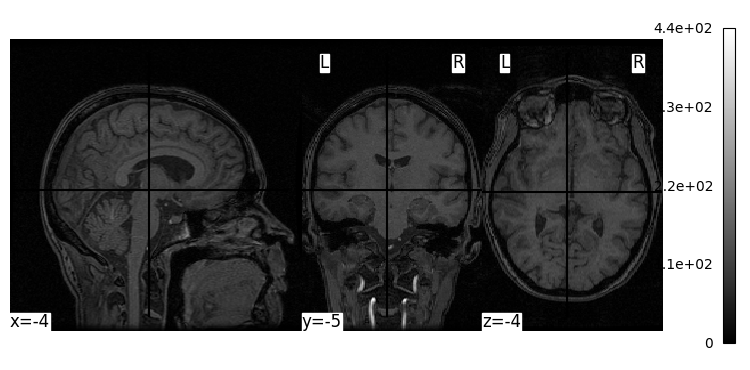

In [2]:
# Plotting anatomical slices from structural MRI from first participant in Haxby dataset

haxby = datasets.fetch_haxby(subjects=1)

anats_all_subjects = (
    Path(datasets.get_data_dirs()[0]) / "haxby2001" / "subj*" / "anat*"
)

plotting.plot_img(haxby.anat[0])


Let's smooth the data a bit with a Gaussian kernel. Essentially, what we're doing is replacing each pixel in our image with a weighted average of its surrounding pixels, which introduces some natural blurring and leads to smoother transitions from pixel to pixel.

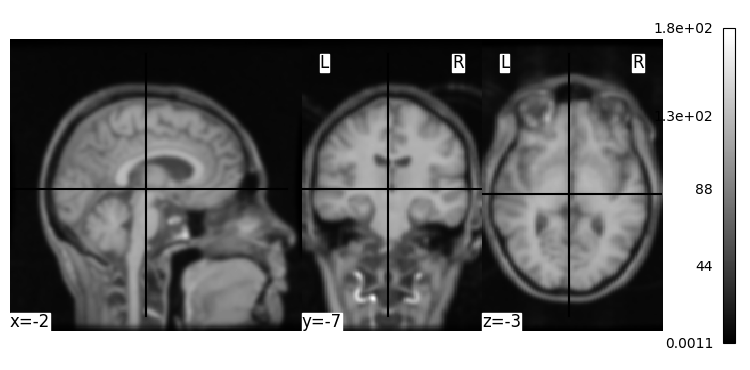

In [19]:
# Plotting smoothed anatomical slices from first participant in Haxby dataset

anats_all_subjects_smooth = image.smooth_img(anats_all_subjects, fwhm=4)

plotting.plot_img(anats_all_subjects_smooth)

><b>Task</b>: Try using different numbers for the full-width half-maximum (<code>fwhm</code>) input argument. How does this change the quality of your smoothed image?

smaller number = more detail

Structural MRI is great, but what we're interested in is viewing how activity in the brain might change while this participant is viewing pictures of houses and faces. To understand this, we need to look at fMRI images. Below, we'll plot some of these images from our participant.

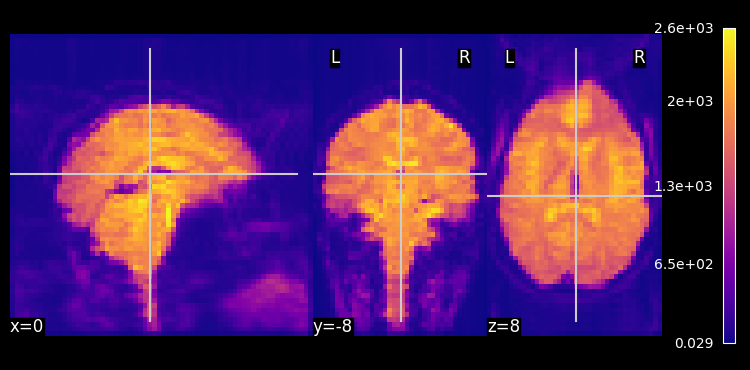

In [20]:
# Plotting fMRI slices from first participant in Haxby dataset.

fmri_filename = haxby.func[0]

from nilearn.image import mean_img
from nilearn.plotting import plot_epi, plot_roi, show

plot_epi(mean_img(fmri_filename), cmap = 'plasma')

show()

><b>Task</b>: Try different colormap options for this dataset. Which do you prefer? List of <code>matplotlib</code> colormaps can be found <a href="https://matplotlib.org/stable/users/explain/colors/colormaps.html">here</a>.

#Referencing specific areas of the brain

Seeing BOLD signals in a picture of the brain can be informative; however, we need some way of understanding where in the brain these signals are located. A useful way of finding this information out is to use a reference atlas. Many exist for the human brain; we're going to use the <a href="https://cma.mgh.harvard.edu/wp-content/uploads/2023/04/HOA-Subcortical-Brain-Structure-Segmentation-Manual.pdf">Harvard Oxford atlas</a>.

[fetch_atlas_harvard_oxford] Dataset created in /root/nilearn_data/fsl

[fetch_atlas_harvard_oxford] Downloading data from https://www.nitrc.org/frs/download.php/9902/HarvardOxford.tgz 
...

[fetch_atlas_harvard_oxford]  ...done. (1 seconds, 0 min)

[fetch_atlas_harvard_oxford] Extracting data from 
/root/nilearn_data/fsl/5c734f16e50cc772ef593cab9bb3137b/HarvardOxford.tgz...

[fetch_atlas_harvard_oxford] .. done.

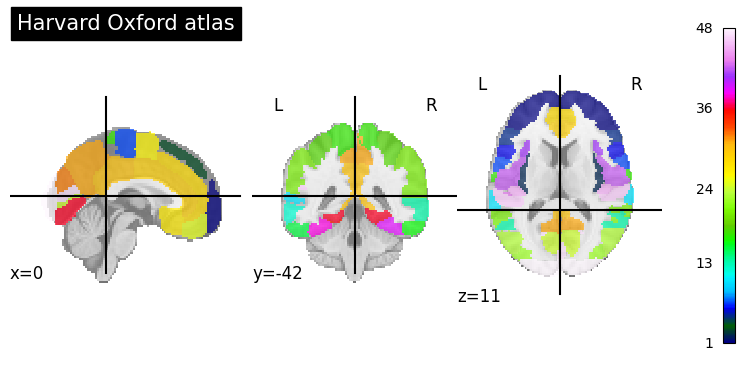

In [5]:
# Plotting Harvard Oxford reference atlas.

dataset_ho = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")
atlas_ho_filename = dataset_ho.filename

from nilearn.plotting import plot_roi, show

plot_roi(atlas_ho_filename, title="Harvard Oxford atlas")


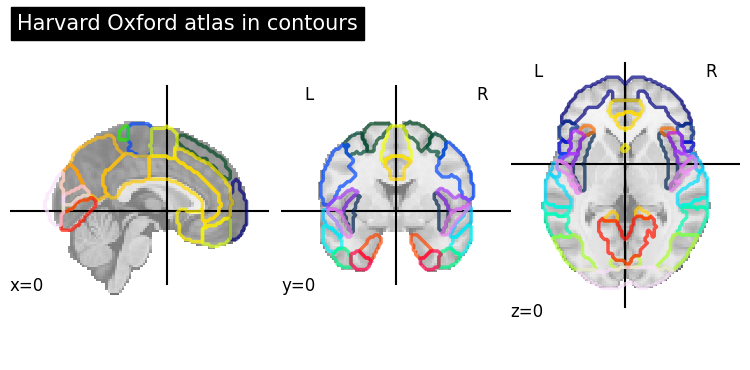

In [6]:
# Plot Harvard Oxford reference atlas with contours

plot_roi(
    atlas_ho_filename,
    view_type="contours",
    title="Harvard Oxford atlas in contours",
)
show()

><b>Task</b>: Use online resources to cross-reference some of the structures outlined in the Harvard Oxford atlas with your participant's fMRI data. Can you identify any areas of the brain that seem to be especially active in your participant? It may be useful to peruse the Allen Brain Institute <a href="https://atlas.brain-map.org/atlas?atlas=265297126#atlas=265297126&plate=111257682&structure=10155&x=40320&y=46976&zoom=-7&resolution=124.49&z=3">human brain atlas</a> to look at some slices with labels.

#Different ways of plotting

Here, we will go over some different ways of plotting fMRI scan images for increased clarity (and different aesthetics!)

Another useful method to visualize our data might be to plot our participant's fMRI scans within an image of a defined brain so that we can see how the two overlap. This method is called "glass brain mapping".

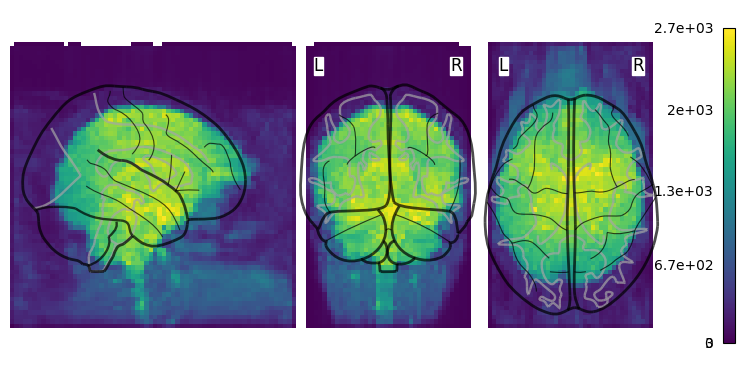

In [7]:
# Plot a glass brain image of the first participant's fMRI data

plotting.plot_glass_brain(mean_img(fmri_filename), threshold=3, cmap = 'viridis')

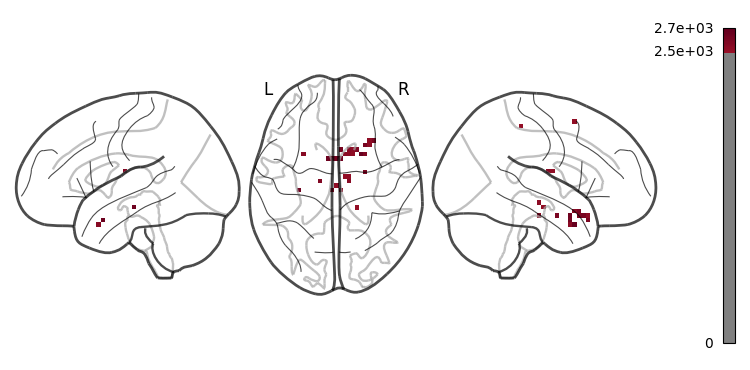

In [30]:
# Plot a glass brain image of the sign of the activation, only in coronal and axial projections

plotting.plot_glass_brain(mean_img(fmri_filename), threshold=2500, plot_abs=False, display_mode="lzr")

><b>Question</b>: The above code plots both negative and positive BOLD values, which is useful if you are comparing activation levels during certain conditions with some sort of "baseline" level of activity. Change the <code>plot_abs</code> input to <code>True</code> - does anything change?

when true, only values are positive, shows increases

><b>Task</b>: Change the <code>threshold</code> and <code>vmin</code> inputs in the above code cell and re-plot. What do these inputs do?

when threshold increases, the range of values shown decreases

><b>Task</b>: Set the <code>display_mode</code> input to <code>lzr</code>. What does this input do? Do you notice any differences in BOLD activity between the left and right hemispheres in this participant?

No notable differences with no threshold, with higher threshold R seems to have more activity

Let's plot contours of our activation spots in a 3D image of our "glass brain" below:

/usr/local/lib/python3.12/dist-packages/matplotlib/colors.py:2294: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


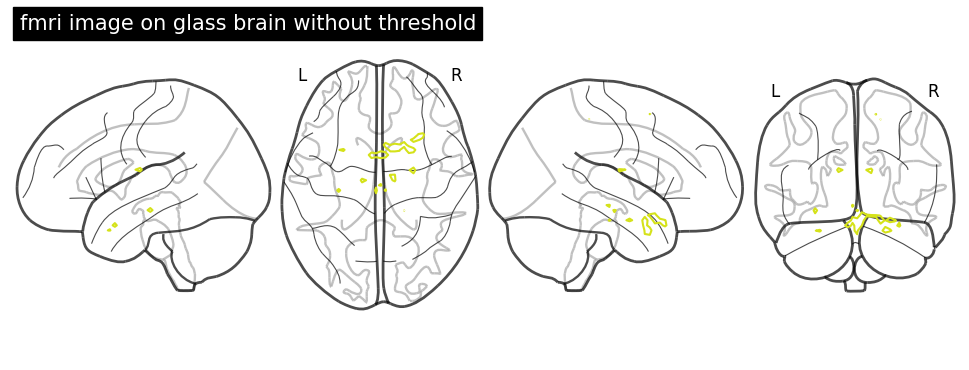

In [38]:
# Plot contours of activation spots on fMRI slices

display = plotting.plot_glass_brain(None, display_mode="lzry")
# Here, we project statistical maps
display.add_contours(mean_img(fmri_filename), filled=True, levels=[2500])
# and add a title
display.title('fmri image on glass brain without threshold')

><b>Task</b>: Set <code>filled</code> equal to <code>True</code> as input to <code>display.add_contours</code>. What does this do?

><b>Task</b>: Set a threshold for your contours - something that will only capture high amounts of activity. Look at the numbers on your colorbar to choose an appropriate threshold value. Do this by adding <code>levels = [number]</code> to the input of <code>display.add_contours</code>. Now, go back and check the left and right hemispheres with your threshold - do you now see any hemispheric differences in activation?

One way to increase interpretation of our image is to create a mesh overlay of our participant's brain (an overlay that contains representations of all cortical gyri and sulci), and map our participant's BOLD activity on top of this overlay. We'll do this below:

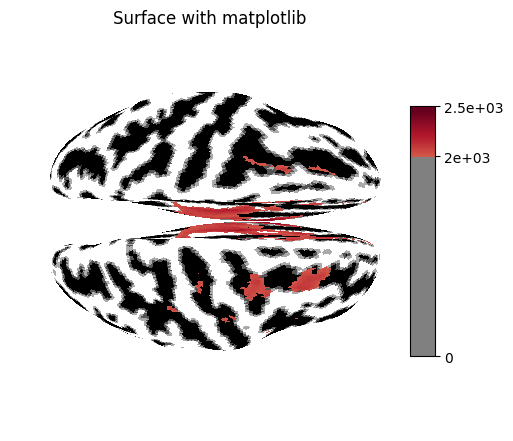

In [10]:
# Make surface image of 3D statistical plot from first fMRI participant

from nilearn.datasets import load_fsaverage

fsaverage_meshes = load_fsaverage()

from nilearn.surface import SurfaceImage

surface_image = SurfaceImage.from_volume(
    mesh=fsaverage_meshes["pial"],
    volume_img=mean_img(fmri_filename),
)

import numpy as np

from nilearn.datasets import load_fsaverage_data

curv_sign = load_fsaverage_data(data_type="curvature")
for hemi, data in curv_sign.data.parts.items():
    curv_sign.data.parts[hemi] = np.sign(data)

from nilearn.plotting import plot_surf_stat_map

# In this example we will plot both hemispheres, but you can choose one of
# "left", "right" or "both".
hemi = "both"

fig = plot_surf_stat_map(
    stat_map=surface_image,
    surf_mesh=fsaverage_meshes["inflated"],
    hemi=hemi,
    title="Surface with matplotlib",
    threshold=2000,
    bg_map=curv_sign,
)
fig.show()

Next, we'll map contours from a couple of brain regions (grabbed from our Harvard Oxford reference atlas) on top of our mesh brain:

[fetch_atlas_surf_destrieux] Dataset found in /root/nilearn_data/destrieux_surface

/tmp/ipykernel_9142/679138777.py:6: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  destrieux = fetch_atlas_surf_destrieux()
/tmp/ipykernel_9142/679138777.py:6: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  destrieux = fetch_atlas_surf_destrieux()


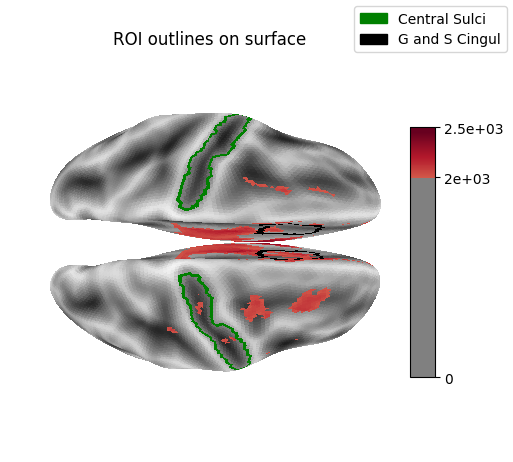

In [41]:
# Map regions of interest onto your surface plot.

from nilearn.datasets import fetch_atlas_surf_destrieux

fsaverage = load_fsaverage("fsaverage5")
destrieux = fetch_atlas_surf_destrieux()
destrieux_atlas = SurfaceImage(
    mesh=fsaverage["inflated"],
    data={
        "left": destrieux["map_left"],
        "right": destrieux["map_right"],
    },
)

# these are the regions we want to outline
regions_dict = {
    "S_central": "Central Sulci",
    "G_and_S_cingul-Mid-Ant": "G and S Cingul",
}

# get indices in atlas for these labels
regions_indices = [
    np.where(np.array(destrieux.labels) == region)[0][0]
    for region in regions_dict
]

labels = list(regions_dict.values())

from nilearn.plotting import plot_surf_contours

fsaverage_sulcal = load_fsaverage_data(data_type="sulcal", mesh_type="pial")

figure = plot_surf_stat_map(
    stat_map=surface_image,
    surf_mesh=fsaverage_meshes["inflated"],
    hemi=hemi,
    title="ROI outlines on surface",
    threshold=2000,
    bg_map=fsaverage_sulcal,
)

figure = plot_surf_contours(
        roi_map=destrieux_atlas,
        hemi=hemi,
        labels=labels,
        levels=regions_indices,
        figure=figure,
        legend=True,
        colors=["g", "k"],
    )

figure.show()

><b>Task</b>: Look at some different brain areas, and try to find areas that capture this participant's patterns of BOLD activity. You can view a list of areas that can be used as input by calling <code>destrieux.labels</code> in a new code cell. Try some different ones by modifying the code cell above!

In [39]:
destrieux.labels

['Unknown',
 'G_and_S_frontomargin',
 'G_and_S_occipital_inf',
 'G_and_S_paracentral',
 'G_and_S_subcentral',
 'G_and_S_transv_frontopol',
 'G_and_S_cingul-Ant',
 'G_and_S_cingul-Mid-Ant',
 'G_and_S_cingul-Mid-Post',
 'G_cingul-Post-dorsal',
 'G_cingul-Post-ventral',
 'G_cuneus',
 'G_front_inf-Opercular',
 'G_front_inf-Orbital',
 'G_front_inf-Triangul',
 'G_front_middle',
 'G_front_sup',
 'G_Ins_lg_and_S_cent_ins',
 'G_insular_short',
 'G_occipital_middle',
 'G_occipital_sup',
 'G_oc-temp_lat-fusifor',
 'G_oc-temp_med-Lingual',
 'G_oc-temp_med-Parahip',
 'G_orbital',
 'G_pariet_inf-Angular',
 'G_pariet_inf-Supramar',
 'G_parietal_sup',
 'G_postcentral',
 'G_precentral',
 'G_precuneus',
 'G_rectus',
 'G_subcallosal',
 'G_temp_sup-G_T_transv',
 'G_temp_sup-Lateral',
 'G_temp_sup-Plan_polar',
 'G_temp_sup-Plan_tempo',
 'G_temporal_inf',
 'G_temporal_middle',
 'Lat_Fis-ant-Horizont',
 'Lat_Fis-ant-Vertical',
 'Lat_Fis-post',
 'Medial_wall',
 'Pole_occipital',
 'Pole_temporal',
 'S_calcarin

#Extracting BOLD activity

Viewing BOLD activity on our participant's brain is a good start, but what we're really interested in is seeing how this activity changes over time (when the participant is viewing different objects, such as faces and houses). In order to do this, we need to first create a whole-brain "mask", which will get rid of any background noise in our dataset (isolating signal that comes only from the brain). We will then extract BOLD signal from each voxel in this mask over the length of the imaging session.

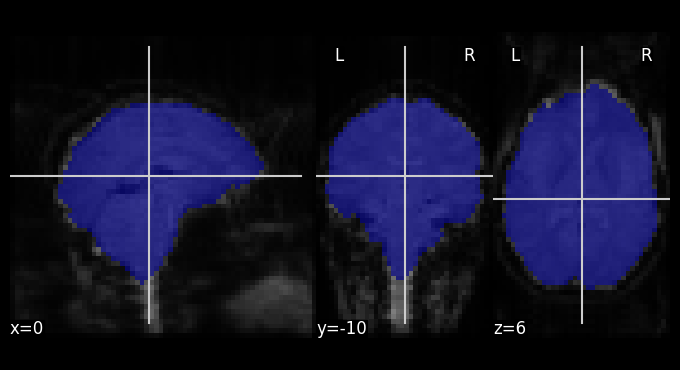

In [12]:
# Extract a whole-brain mask from our fMRI data (get rid of background noise)

from nilearn.masking import compute_epi_mask

mask_img = compute_epi_mask(fmri_filename)

# Visualize it as an ROI
from nilearn.plotting import plot_roi

plot_roi(mask_img, mean_img(fmri_filename), colorbar=False)

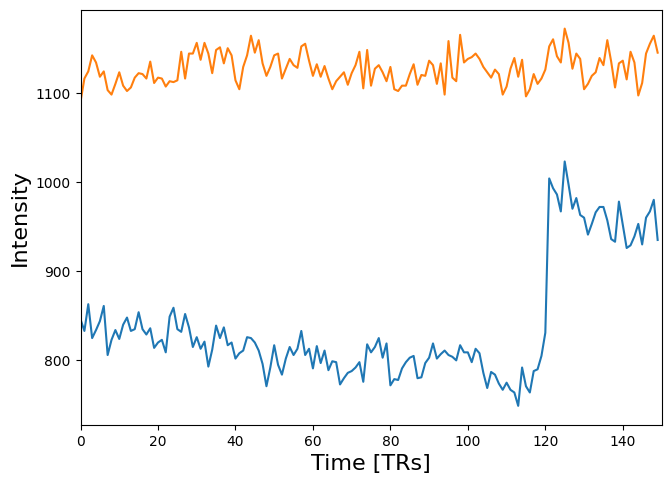

In [13]:
# Plot 2D extracted BOLD activity from two voxels of our brain mask over time.

from nilearn.masking import apply_mask

masked_data = apply_mask(fmri_filename, mask_img)

# masked_data shape is (timepoints, voxels). We can plot the first 150
# timepoints from two voxels

# And now plot a few of these
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(masked_data[:150, :2])
plt.xlabel("Time [TRs]", fontsize=16)
plt.ylabel("Intensity", fontsize=16)
plt.xlim(0, 150)
plt.subplots_adjust(bottom=0.12, top=0.95, right=0.95, left=0.12)

show()

><b>Question</b>: How do other voxels in our image compare to the first two? Map BOLD activity from different voxels in the dataset, and see how activity in those voxels differs across time.



#Quantifying activity in the ventral temporal cortex

Now that we've isolated whole-brain activity, we need to have some way of analyzing activity from just our region of interest - which, in this case, is the ventral temporal cortex, a major part of the ventral visual stream in humans. We can use our Harvard Oxford atlas to outline this region and superimpose it on our participant's brain scan, and then only select voxels from this region for further analysis. Within the ventral temporal cortex, we will also create a mask for the fusiform face area (FFA), an area of the brain that is thought to be responsible for processing faces. We can use these masks to answer the question: Is face processing contained within the FFA, or is it processed more diffusely throughout the ventral temporal cortex?

/usr/local/lib/python3.12/dist-packages/nilearn/plotting/displays/_axes.py:98: UserWarning: The following kwargs were not used by contour: 'contours', 'linewidth'
  im = getattr(ax, type)(


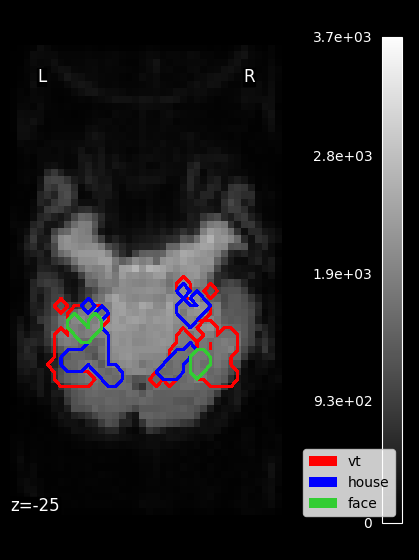

In [42]:
# Plot masks for ROIs for house viewing, face viewing, and the ventral temporal cortex

from nilearn.plotting import plot_anat, show

z_slice = -25

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(4, 5.4), facecolor="k")

display = plot_anat(
    mean_img(fmri_filename), display_mode="z", cut_coords=[z_slice], figure=fig
)
mask_vt_filename = haxby.mask_vt[0]
mask_house_filename = haxby.mask_house[0]
mask_face_filename = haxby.mask_face[0]
masks = [mask_vt_filename, mask_house_filename, mask_face_filename]
colors = ["red", "blue", "limegreen"]
for mask, color in zip(masks, colors, strict=False):
    display.add_contours(
        mask,
        contours=1,
        antialiased=False,
        linewidth=4.0,
        levels=[0],
        colors=[color],
    )

# We generate a legend using the trick described on
# https://matplotlib.org/2.0.2/users/legend_guide.html
from matplotlib.patches import Rectangle

p_v = Rectangle((0, 0), 1, 1, fc="red")
p_h = Rectangle((0, 0), 1, 1, fc="blue")
p_f = Rectangle((0, 0), 1, 1, fc="limegreen")
plt.legend([p_v, p_h, p_f], ["vt", "house", "face"], loc="lower right")

show()

><b>Task</b>: Try different z-slice coordinates, and observe how your masks change as you move through this participant's brain

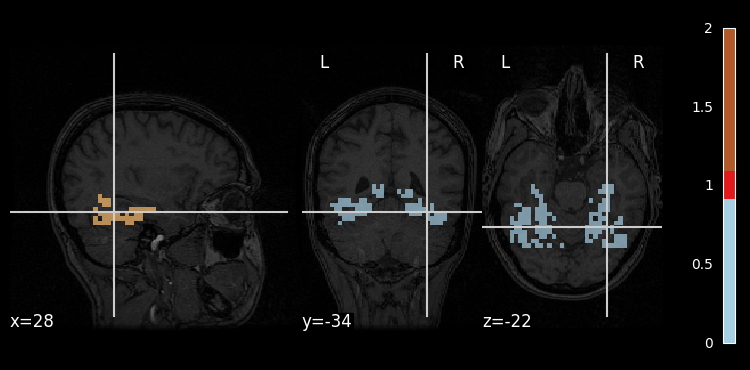

In [15]:
# View the ventral temporal cortex mask plotted on top of our participant's anatomy scan

plot_roi(mask_vt_filename, bg_img=haxby.anat[0], cmap="Paired")

show()

#Machine learning - light introduction

Consider that the goal of inferential statistics (a t-test, for example) is to arrive at some conclusion about a *dataset*. More specifically, in the case of a 1-sample t-test: How likely is it that the mean of a sample distribution is also in a population distribution? For this question, a t-test (our *program*) is a great tool for the job!

One really nice thing about being an experimentalist is that you can (at least *attempt* to) control the conditions that give you your data - in my case, what task are mice running? Which neurons are expressing a virus? Which neurons are turned "on" or "off"? Which stage of training are mice on?

In this way, I *know* my data really well! This is what allows me to make interpretations about what a t-test result means.

What if we *don't* know our data really well? What if we're able to collect some data, but don't have the full picture of what the data represent?

<img src = 'https://drive.google.com/uc?id=1eQeiL6-o7YQXCLpJTQJQeAJFoD3_mZnG' width = "600">

In this case, maybe we can create an algorithm that can guess for us! This problem is at the heart of **classification**, a really common instance of **supervised machine learning**.

<img src = 'https://drive.google.com/uc?id=1oqq0U8iJHYVs6bG1nl-aaYHpseAdpYOm' width = "800">

Linear classifiers try to assign a data point to an outcome - the outcome must be binary (i.e., the data point is either *true* or *false*).

We're going to use some classifiers to see if we can predict the object our participant is viewing (house or face) based on patterns of BOLD activity. If objects and faces are segregated in the ventral temporal cortex, then activity in the FFA should strongly predict face viewing, and activity in other parts of ventral temporal cortex should strongly predict house viewing. If objects and faces are more distributed in the ventral temporal cortex, then whether activity comes from the FFA or elsewhere should not be predictive of what kind of object our participant is viewing.

/tmp/ipykernel_9142/1583410476.py:56: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  decoder.fit(fmri_niimgs_condition, stimuli, groups=run_labels)
/tmp/ipykernel_9142/1583410476.py:56: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  decoder.fit(fmri_niimgs_condition, stimuli, groups=run_labels)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1863: UserWarning: l1_ratios parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1863: UserWarning: l1_

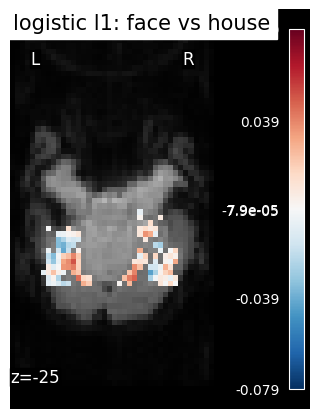

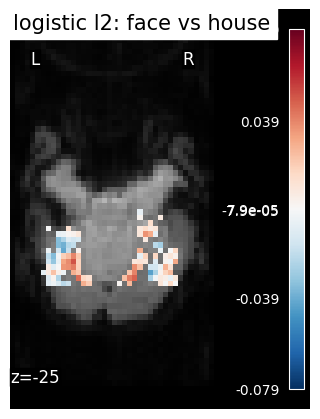

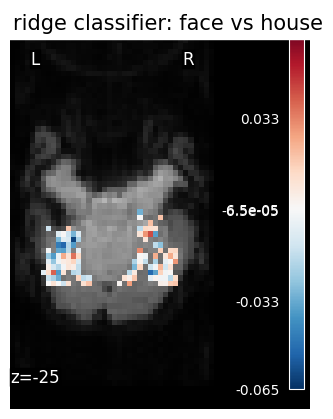

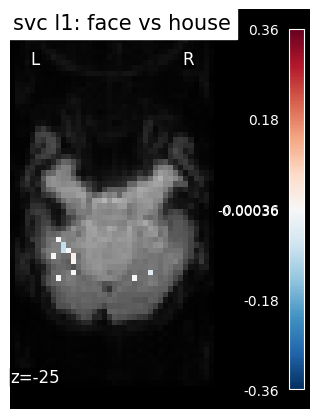

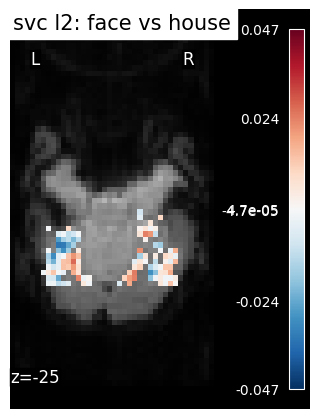

In [16]:
# Try to use different classifiers to predict responses in ventral temporal cortex to "house" or "face"

# load labels
import pandas as pd

labels = pd.read_csv(haxby.session_target[0], sep=" ")
stimuli = labels["labels"]

# identify resting state (baseline) labels in order to be able to remove them
resting_state = stimuli == "rest"

# extract the indices of the images corresponding to some condition or task
task_mask = np.logical_not(resting_state)

# find names of remaining active labels
categories = stimuli[task_mask].unique()

# extract tags indicating to which acquisition run a tag belongs
run_labels = labels["chunks"][task_mask]

# Because the data is in one single large 4D image, we need to use
# index_img to do the split easily.
from nilearn.image import index_img
from nilearn.decoding import Decoder
from sklearn.model_selection import LeaveOneGroupOut
cv = LeaveOneGroupOut()

fmri_niimgs = index_img(fmri_filename, task_mask)
classification_target = stimuli[task_mask]

classifiers = [
    "svc_l2",
    "svc_l1",
    "logistic_l1",
    "logistic_l2",
    "ridge_classifier",
]

condition_mask = np.logical_or(stimuli == "face", stimuli == "house")
stimuli = stimuli[condition_mask]
assert len(stimuli) == 216
fmri_niimgs_condition = index_img(fmri_filename, condition_mask)
run_labels = labels["chunks"][condition_mask]
categories = stimuli.unique()
assert len(categories) == 2

classifiers_data = {}

for classifier_name in sorted(classifiers):
    decoder = Decoder(
        estimator=classifier_name,
        mask=mask_vt_filename,
        cv=cv,
        screening_percentile=100,
    )
    decoder.fit(fmri_niimgs_condition, stimuli, groups=run_labels)
    classifiers_data[classifier_name] = {}
    classifiers_data[classifier_name]["score"] = decoder.cv_scores_
    classifiers_data[classifier_name]["map"] = decoder.coef_img_["face"]

from nilearn.image import get_data
from nilearn.plotting import plot_stat_map, show

for classifier_name in sorted(classifiers):
    coef_img = classifiers_data[classifier_name]["map"]
    threshold = np.max(np.abs(get_data(coef_img))) * 1e-3
    plot_stat_map(
        coef_img,
        bg_img=mean_img(fmri_filename),
        display_mode="z",
        cut_coords=[-25],
        threshold=threshold,
        title=f"{classifier_name.replace('_', ' ')}: face vs house",
        figure=plt.figure(figsize=(3, 4)),
    )

show()

><b>Task</b>: Try all of this with the second participant in the Haxby dataset. How does their data compare to the first participant's data?